<a href="https://colab.research.google.com/github/RohitKhobare/Data-Science-and-Big-Data-Analytics/blob/main/LA_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully! Dimensions:", df.shape)
display(df.head())

Dataset loaded successfully! Dimensions: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Correlation with House Prices (medv):
medv       1.00
rm         0.70
zn         0.36
b          0.33
dis        0.25
chas       0.18
rad       -0.38
age       -0.38
crim      -0.39
nox       -0.43
tax       -0.47
indus     -0.48
ptratio   -0.51
lstat     -0.74
Name: medv, dtype: float64


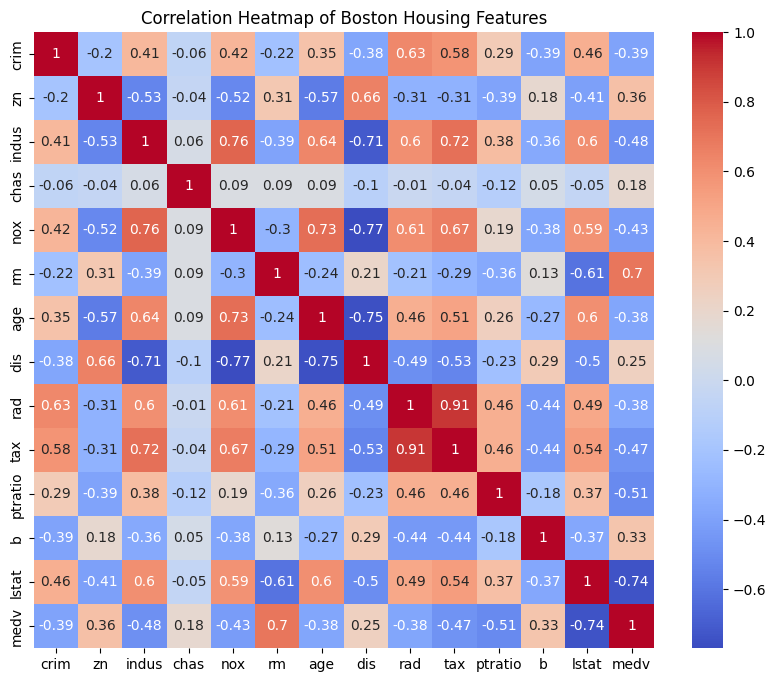

In [3]:
correlation_matrix = df.corr().round(2)

print("Correlation with House Prices (medv):")
print(correlation_matrix['medv'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Boston Housing Features")
plt.show()

In [4]:
X = df.drop('medv', axis=1)

y = df['medv']

print("Features (X) and Target (y) separated successfully.")

Features (X) and Target (y) separated successfully.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} samples")
print(f"Testing data size: {X_test.shape[0]} samples")

Training data size: 404 samples
Testing data size: 102 samples


In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression Model trained successfully!")

Linear Regression Model trained successfully!


In [7]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

--- Model Evaluation ---
Root Mean Squared Error (RMSE): 4.93
R-squared (R2) Score: 0.6688


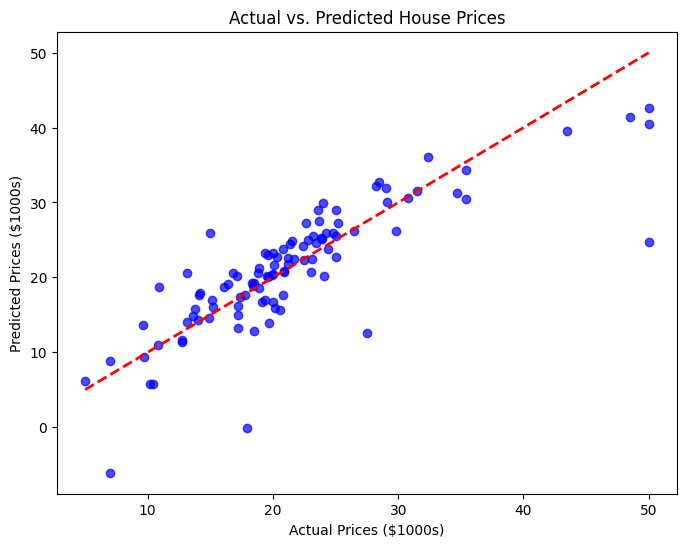

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel("Actual Prices ($1000s)")
plt.ylabel("Predicted Prices ($1000s)")
plt.title("Actual vs. Predicted House Prices")
plt.show()